# Bird Migration — Phase 2: Feature Engineering
**Author:** Jayant Pandey  
**Project:** Bird Migration GPS Tracking — ISI Kolkata IDEAS Internship 2026  

---

## Continuation from Phase 1

This notebook is a direct extension of `jayant_bird_migration_github.ipynb`.

**Phase 1 produced:** `bird_migration_with_climate.csv`
- 61,920 GPS records across 3 White Storks (Eric, Nico, Sanne)
- Aug 2013 to Apr 2014
- Columns: latitude, longitude, altitude, speed_2d, direction, bird_name, date_time, unix_timestamp, day_of_year, hour, temperature, wind_speed, precipitation
- Zero nulls

**Phase 2 adds:** 33 engineered features for K-Means clustering and ML classification

**Phase 2 produces:** `bird_migration_features.csv`

---

| Phase | Notebook | Output |
|-------|----------|--------|
| Phase 1 | `jayant_bird_migration_github.ipynb` | `bird_migration_with_climate.csv` |
| **Phase 2** | **`phase2_feature_engineering.ipynb`** | **`bird_migration_features.csv`** |
| Phase 3 | K-Means Clustering | `bird_migration_clustered.csv` |
| Phase 4 | RF / XGBoost Classification | `test_predictions.csv` |

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print('Imports done.')

Imports done.


## 1. Load Phase 1 Output

Loading `bird_migration_with_climate.csv` — the final output of `jayant_bird_migration_github.ipynb`.

In [2]:
df = pd.read_csv('bird_migration_with_climate.csv')
df['date_time'] = pd.to_datetime(df['date_time'], utc=True)
df = df.sort_values(['bird_name', 'date_time']).reset_index(drop=True)

print('Phase 1 output loaded successfully.')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Nulls:', df.isnull().sum().sum())
df.head(3)

Phase 1 output loaded successfully.
Shape: (61920, 14)
Columns: ['altitude', 'date_time', 'device_info_serial', 'direction', 'latitude', 'longitude', 'speed_2d', 'bird_name', 'unix_timestamp', 'day_of_year', 'hour', 'temperature', 'wind_speed', 'precipitation']
Nulls: 6


,altitude,date_time,device_info_serial,direction,latitude,longitude,speed_2d,bird_name,unix_timestamp,day_of_year,hour,temperature,wind_speed,precipitation
0,71,2013-08-15 00:18:08+00:00,851,-150.469753,49.41986,2.120733,0.150000,Eric,1376525888,227,0,14.3,5.4,0.0
1,68,2013-08-15 00:48:07+00:00,851,-136.151141,49.41988,2.120746,2.438360,Eric,1376527687,227,0,14.3,5.4,0.0
2,68,2013-08-15 01:17:58+00:00,851,160.797477,49.42031,2.120885,0.596657,Eric,1376529478,227,1,13.8,2.3,0.0


## 2. Temporal Features

Extract time-based features and apply cyclic (sin/cos) encoding.

**Why cyclic encoding?**  
Hour 23 and Hour 0 are 1 hour apart but numerically 23 apart. Standard encoding misleads the model. Sin/cos encoding wraps the cycle correctly — 23:00 and 00:00 are treated as close.

In [3]:
df['hour']        = df['date_time'].dt.hour
df['day_of_year'] = df['date_time'].dt.dayofyear
df['month']       = df['date_time'].dt.month

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin']  = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['day_cos']  = np.cos(2 * np.pi * df['day_of_year'] / 365)

print('Temporal features added.')
df[['hour', 'day_of_year', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']].head(3)

Temporal features added.


,hour,day_of_year,hour_sin,hour_cos,day_sin,day_cos
0,0,227,0.000000,1.000000,-0.693281,-0.720667
1,0,227,0.000000,1.000000,-0.693281,-0.720667
2,1,227,0.258819,0.965926,-0.693281,-0.720667


## 3. Season Encoding

Three biological seasons based on date:
- **1 = Autumn migration** (Aug–Nov 2013) — southward journey
- **2 = Wintering** (Dec 2013–Jan 2014) — resting in West Africa
- **3 = Spring return** (Feb–Apr 2014) — northward journey

In [4]:
def encode_season(month):
    if month in [8, 9, 10, 11]:
        return 1
    elif month in [12, 1]:
        return 2
    else:
        return 3

df['season'] = df['month'].apply(encode_season)

print('Season distribution:')
print(df['season'].value_counts().sort_index())
print('1=Autumn migration, 2=Wintering, 3=Spring return')

Season distribution:
season
1    25934
2    15265
3    20721
Name: count, dtype: int64
1=Autumn migration, 2=Wintering, 3=Spring return


## 4. Time Delta

Time elapsed (seconds) between consecutive GPS observations per bird.

**Why?** GPS is not sampled at perfectly equal intervals. Acceleration and distance features depend on elapsed time. Time_Delta gives models this context explicitly.

In [5]:
df['unix_timestamp'] = df['date_time'].astype(np.int64) // 10**9
df['time_delta'] = df.groupby('bird_name')['unix_timestamp'].diff().fillna(0)

print('Time delta stats (seconds):')
print(df['time_delta'].describe())

Time delta stats (seconds):
count     61920.000000
mean       1084.110998
std        2206.002881
min           0.000000
25%         896.000000
50%         900.000000
75%         926.000000
max      400694.000000
Name: time_delta, dtype: float64


## 5. Kinematic Features

Describe **how** the bird is moving — not just where it is.

These are among the most important features because migration behaviour (active flying vs resting at stopovers) is captured in movement dynamics, not just position.

### 5.1 Haversine Distance  
**Great‑circle distance (km)** between consecutive GPS points  
We are using the *Haversine formula* — accounts for Earth’s curvature.


In [6]:


def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

lat_prev = df.groupby('bird_name')['latitude'].shift(1)
lon_prev = df.groupby('bird_name')['longitude'].shift(1)

df['haversine_dist'] = haversine(
    lat_prev.fillna(df['latitude']),
    lon_prev.fillna(df['longitude']),
    df['latitude'],
    df['longitude']
)

print('Haversine distance (km):')
print(df['haversine_dist'].describe())

Haversine distance (km):
count    61920.000000
mean         1.115219
std          2.971018
min          0.000000
25%          0.013226
50%          0.078487
75%          0.487353
max         78.698804
Name: haversine_dist, dtype: float64


#### 5.2 Bearing
Direction of travel between consecutive GPS fixes (0-360 degrees)  
0=North, 90=East, 180=South, 270=West


In [7]:


def compute_bearing(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    bearing = np.degrees(np.arctan2(x, y))
    return (bearing + 360) % 360

df['bearing'] = compute_bearing(
    lat_prev.fillna(df['latitude']),
    lon_prev.fillna(df['longitude']),
    df['latitude'],
    df['longitude']
)

print('Bearing (degrees 0-360):')
print(df['bearing'].describe())

Bearing (degrees 0-360):
count    61920.000000
mean       180.192870
std        103.632518
min          0.000000
25%         92.800267
50%        181.732397
75%        267.127242
max        359.994180
Name: bearing, dtype: float64


### 5.3 Acceleration 
Rate of change in speed between consecutive observations (m/s²)

In [8]:


speed_prev = df.groupby('bird_name')['speed_2d'].shift(1)

df['acceleration'] = (
    (df['speed_2d'] - speed_prev.fillna(df['speed_2d'])) /
    df['time_delta'].replace(0, np.nan)
).fillna(0)

print('Acceleration (m/s²):')
print(df['acceleration'].describe())

Acceleration (m/s²):
count    61920.000000
mean         0.000016
std          0.004574
min         -0.069301
25%         -0.001249
50%          0.000004
75%          0.001294
max          0.066828
Name: acceleration, dtype: float64


### 5.4 Turning Rate 
 How fast the bird is changing direction (degrees per second)
 High turning rate = active manoeuvring; Low = straight migration flight

In [9]:

bearing_prev = df.groupby('bird_name')['bearing'].shift(1)
bearing_diff = (df['bearing'] - bearing_prev.fillna(df['bearing'])).abs()
bearing_diff = bearing_diff.apply(lambda x: x if x <= 180 else 360 - x)

df['turning_rate'] = (
    bearing_diff / df['time_delta'].replace(0, np.nan)
).fillna(0)

print('Turning rate (degrees/second):')
print(df['turning_rate'].describe())

Turning rate (degrees/second):
count    61920.000000
mean         0.080001
std          0.062627
min          0.000000
25%          0.022301
50%          0.067650
75%          0.133755
max          0.202607
Name: turning_rate, dtype: float64


###  5.5 Is Resting Flag 
 Binary: 1 if speed < 1 m/s (anchored/resting), 0 if actively moving
 EDA finding: 44.9% of records have speed < 1 m/s

### Resting Behaviour Feature Summary

The `is_resting` feature was created using a threshold of **1.0 m/s** on horizontal speed (`speed_2d`).

This threshold was selected after examining the empirical speed distribution, which showed a strong concentration of observations at low speeds followed by a gradual decline toward higher flight speeds.

The resulting feature classified:

- **Resting observations:** 28,018 (45.25%)
- **Active observations:** 33,902 (54.75%)

The relatively balanced distribution suggests that the feature provides useful behavioural information for downstream machine learning models while remaining simple and interpretable.

Speed Statistics
count    61917.000000
mean         2.558799
std          3.577099
min          0.000000
25%          0.410000
50%          1.209339
75%          3.057924
max         63.488066
Name: speed_2d, dtype: float64

Selected Percentiles
0.01    0.044721
0.05    0.106301
0.10    0.170294
0.25    0.410000
0.50    1.209339
Name: speed_2d, dtype: float64


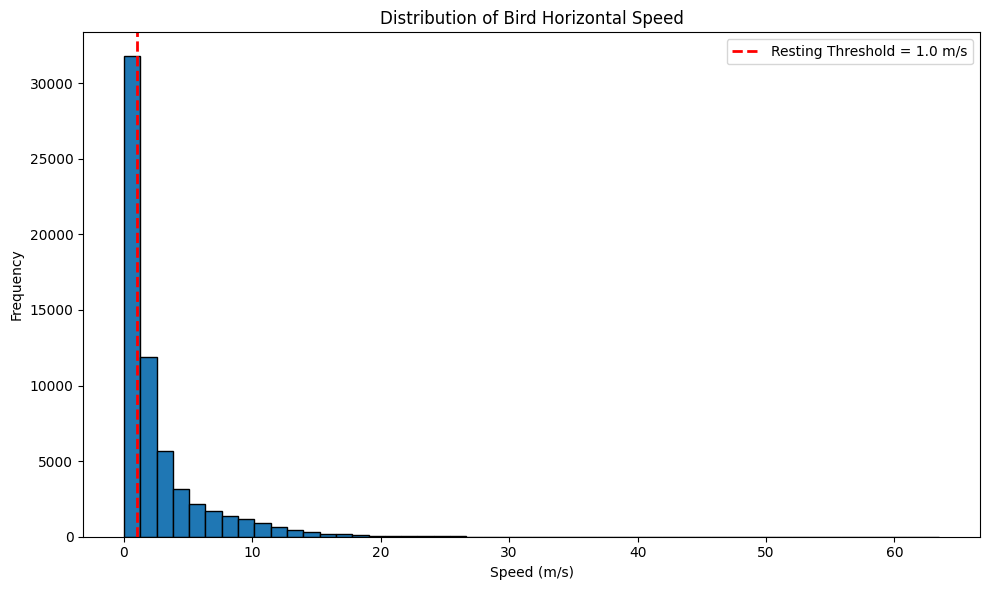

In [22]:

import matplotlib.pyplot as plt

print("=" * 60)
print("Speed Statistics")
print("=" * 60)

print(df['speed_2d'].describe())

print("\nSelected Percentiles")
print(df['speed_2d'].quantile([0.01, 0.05, 0.10, 0.25, 0.50]))

plt.figure(figsize=(10,6))

plt.hist(df['speed_2d'].dropna(),
         bins=50,
         edgecolor='black')

plt.axvline(
    x=1.0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Resting Threshold = 1.0 m/s'
)

plt.title("Distribution of Bird Horizontal Speed")
plt.xlabel("Speed (m/s)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(
    "figures/Figure_01_Bird_Speed_Distribution_Full.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

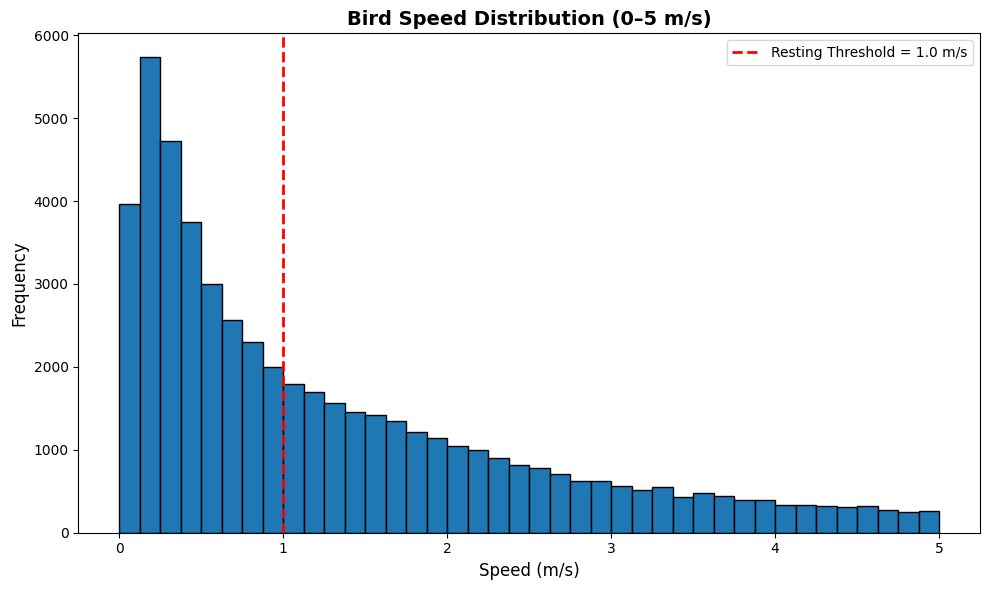

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    df[df['speed_2d'] <= 5]['speed_2d'],
    bins=40,
    edgecolor='black'
)

plt.axvline(
    1.0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Resting Threshold = 1.0 m/s'
)

plt.title("Bird Speed Distribution (0–5 m/s)", fontsize=14, fontweight='bold')
plt.xlabel("Speed (m/s)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()

# Improve layout
plt.tight_layout()

# Save the figure (300 DPI for publication/report quality)
plt.savefig(
    "bird_speed_distribution_0_5ms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:

df['is_resting'] = (df['speed_2d'] < 1.0).astype(int)

print('Resting records:', df['is_resting'].sum())
print('Moving records:', (df['is_resting'] == 0).sum())
print('Resting percentage:', round(df['is_resting'].mean() * 100, 1), '%')

Resting records: 28018
Moving records: 33902
Resting percentage: 45.2 %


In [19]:
import os

os.makedirs("figures", exist_ok=True)

In [20]:
plt.savefig(
    "figures/Figure_2_Bird_Speed_Distribution_0_5ms.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [21]:
print(df['speed_2d'].describe())

print("\nPercentiles")

print(df['speed_2d'].quantile([
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]))

count    61917.000000
mean         2.558799
std          3.577099
min          0.000000
25%          0.410000
50%          1.209339
75%          3.057924
max         63.488066
Name: speed_2d, dtype: float64

Percentiles
0.01     0.044721
0.05     0.106301
0.10     0.170294
0.25     0.410000
0.50     1.209339
0.75     3.057924
0.90     7.146623
0.95    10.079053
0.99    16.011162
Name: speed_2d, dtype: float64


### Resting behaviour summary

In [23]:

resting_counts = df['is_resting'].value_counts().sort_index()

print(resting_counts)

print("\nPercentages")

print((df['is_resting']
       .value_counts(normalize=True)
       .sort_index()*100)
      .round(2))

is_resting
0    33902
1    28018
Name: count, dtype: int64

Percentages
is_resting
0    54.75
1    45.25
Name: proportion, dtype: float64


## 6. Outlier Flagging

Identified during Phase 1 EDA:
- Altitude: -1010m (below sea level) and +6965m (near Everest) — GPS sensor errors
- Speed: 63.5 m/s (228 km/h) — physically impossible for a stork

Flagged with binary columns rather than removed — they do not affect the classification features directly.

In [11]:
df['altitude_outlier'] = ((df['altitude'] < -1000) | (df['altitude'] > 6900)).astype(int)
df['speed_outlier']    = (df['speed_2d'] > 60).astype(int)

print('Altitude outliers flagged:', df['altitude_outlier'].sum())
print('Speed outliers flagged:', df['speed_outlier'].sum())

Altitude outliers flagged: 2
Speed outliers flagged: 1


## 7. Lag Features

Give classical ML models short-term memory — what was the bird doing 1 and 2 timesteps ago?

**Why?** Unlike GRU which has built-in memory via hidden states, Random Forest and XGBoost have no memory. Lag features explicitly provide recent history as input columns — this is the standard technique to give classical ML models temporal awareness.

In [12]:
for col in ['latitude', 'longitude', 'speed_2d', 'bearing']:
    df[f'{col}_lag1'] = df.groupby('bird_name')[col].shift(1)
    df[f'{col}_lag2'] = df.groupby('bird_name')[col].shift(2)

lag_cols = [c for c in df.columns if 'lag' in c]
df[lag_cols] = df[lag_cols].fillna(0)

print('Lag features added:')
print(lag_cols)

Lag features added:
['latitude_lag1', 'latitude_lag2', 'longitude_lag1', 'longitude_lag2', 'speed_2d_lag1', 'speed_2d_lag2', 'bearing_lag1', 'bearing_lag2']


## 8. Rolling Features

Moving averages and standard deviations over a window of 5 readings to smooth GPS noise.

**Why window=5?** GPS records are approximately every 30 minutes. A window of 5 covers ~2.5 hours — enough to capture short-term behaviour patterns without smoothing away meaningful variation.

In [13]:
WINDOW = 5

df['rolling_mean_speed']   = df.groupby('bird_name')['speed_2d'].transform(
    lambda x: x.rolling(WINDOW, min_periods=1).mean()
)
df['rolling_std_speed']    = df.groupby('bird_name')['speed_2d'].transform(
    lambda x: x.rolling(WINDOW, min_periods=1).std()
).fillna(0)
df['rolling_mean_heading'] = df.groupby('bird_name')['bearing'].transform(
    lambda x: x.rolling(WINDOW, min_periods=1).mean()
)

print('Rolling features added (window=5).')
df[['rolling_mean_speed', 'rolling_std_speed', 'rolling_mean_heading']].describe()

Rolling features added (window=5).


,rolling_mean_speed,rolling_std_speed,rolling_mean_heading
count,61920.000000,61920.000000,61920.000000
mean,2.559020,2.395527,180.179836
std,2.174082,2.086555,53.765040
min,0.055078,0.000000,0.000000
25%,1.129625,0.921934,146.473749
50%,1.946710,1.766906,182.485269
75%,3.279892,3.337412,215.875360
max,25.901660,27.796989,354.450377


## 9. Environmental Change Features

Rate of change in environmental conditions between consecutive GPS readings.

**Why?** A bird deciding to migrate responds to changing weather, not just current weather. Temperature dropping 5°C overnight is more informative than absolute temperature = 15°C.

In [14]:
df['temperature_change'] = df.groupby('bird_name')['temperature'].diff().fillna(0)
df['wind_speed_change']  = df.groupby('bird_name')['wind_speed'].diff().fillna(0)
df['altitude_change']    = df.groupby('bird_name')['altitude'].diff().fillna(0)

print('Environmental change features added.')
df[['temperature_change', 'wind_speed_change', 'altitude_change']].describe()

Environmental change features added.


,temperature_change,wind_speed_change,altitude_change
count,61920.000000,61920.000000,61920.000000
mean,-0.000210,-0.000107,-0.007752
std,0.557954,1.105913,112.651446
min,-13.300000,-24.400000,-6950.000000
25%,0.000000,0.000000,-11.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,11.000000
max,11.300000,21.200000,7104.000000


## 10. Final Feature Summary

In [15]:
SPATIAL     = ['latitude', 'longitude', 'altitude']
KINEMATIC   = ['speed_2d', 'bearing', 'acceleration', 'turning_rate',
               'haversine_dist', 'is_resting']
TEMPORAL    = ['hour', 'day_of_year', 'hour_sin', 'hour_cos',
               'day_sin', 'day_cos', 'season', 'time_delta']
LAG         = ['latitude_lag1', 'latitude_lag2',
               'longitude_lag1', 'longitude_lag2',
               'speed_2d_lag1', 'speed_2d_lag2',
               'bearing_lag1', 'bearing_lag2']
ROLLING     = ['rolling_mean_speed', 'rolling_std_speed', 'rolling_mean_heading']
ENVIRONMENT = ['temperature', 'wind_speed', 'precipitation',
               'temperature_change', 'wind_speed_change', 'altitude_change']
CATEGORICAL = ['bird_name']
FLAGS       = ['altitude_outlier', 'speed_outlier']

ALL_FEATURES = SPATIAL + KINEMATIC + TEMPORAL + LAG + ROLLING + ENVIRONMENT + CATEGORICAL + FLAGS

print('=== FEATURE ENGINEERING SUMMARY ===')
print(f'Spatial:          {len(SPATIAL):>3} features  — where the bird is')
print(f'Kinematic:        {len(KINEMATIC):>3} features  — how the bird is moving')
print(f'Temporal:         {len(TEMPORAL):>3} features  — when it is moving')
print(f'Lag:              {len(LAG):>3} features  — what it was doing recently')
print(f'Rolling:          {len(ROLLING):>3} features  — smoothed behaviour summaries')
print(f'Environmental:    {len(ENVIRONMENT):>3} features  — surrounding conditions')
print(f'Categorical:      {len(CATEGORICAL):>3} feature   — bird identity')
print(f'Flags:            {len(FLAGS):>3} features  — sensor error indicators')
print(f'-----------------------------------')
print(f'Total:            {len(ALL_FEATURES):>3} features')
print()

null_check = df[ALL_FEATURES].isnull().sum()
if null_check.sum() == 0:
    print('Null check: PASSED — zero nulls across all features')
else:
    print('Null check: FAILED — nulls found:')
    print(null_check[null_check > 0])

=== FEATURE ENGINEERING SUMMARY ===
Spatial:            3 features  — where the bird is
Kinematic:          6 features  — how the bird is moving
Temporal:           8 features  — when it is moving
Lag:                8 features  — what it was doing recently
Rolling:            3 features  — smoothed behaviour summaries
Environmental:      6 features  — surrounding conditions
Categorical:        1 feature   — bird identity
Flags:              2 features  — sensor error indicators
-----------------------------------
Total:             37 features

Null check: FAILED — nulls found:
speed_2d    3
dtype: int64


## 11. Save Output for Phase 3

In [16]:
SAVE_COLS = ['date_time', 'unix_timestamp'] + ALL_FEATURES
SAVE_COLS = list(dict.fromkeys(SAVE_COLS))

df[SAVE_COLS].to_csv('bird_migration_features.csv', index=False)

print('Saved: bird_migration_features.csv')
print('Shape:', df[SAVE_COLS].shape)
print()
print('Next: Phase 3 — K-Means Clustering on lat/lon to create migration zones')

Saved: bird_migration_features.csv
Shape: (61920, 39)

Next: Phase 3 — K-Means Clustering on lat/lon to create migration zones
